# Univariate and Bivariate Analysis of Application (Living Region) Data
- table - application_train.csv
---

__Region where client lives info__:
- `REGION_POPULATION_RELATIVE` - Normalized population of region where client lives (higher number means the client lives in more populated)
- `REGION_RATING_CLIENT` - Our rating of the region where client lives (1,2,3)
- `REGION_RATING_CLIENT_W_CITY` Our rating of the region where client lives with taking city into account (1,2,3)

## 0. Data and librarires

In [72]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_categorical_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_categorical_distribution, plot_quantitative_vs_binary,
    plot_categorical_vs_binary
)
from preprocess_module import (
    create_imputed_quantitative_features, filter_high_nans_cols, drop_obs_with_nans_in_low_nan_cols,
    trim_quantitative_var, cap_quantitative_var, categorical_target_summary, bin_quantitative_var
)

In [ ]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
region_cols = ['REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']
app_df[['TARGET'] + region_cols].head()

,TARGET,REGION_POPULATION_RELATIVE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY
0,1,0.018801,2,2
1,0,0.003541,1,1
2,0,0.010032,2,2
3,0,0.008019,2,2
4,0,0.028663,2,2


In [75]:
app_df[['TARGET'] + region_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 4 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   TARGET                       307511 non-null  int64  
 1   REGION_POPULATION_RELATIVE   307511 non-null  float64
 2   REGION_RATING_CLIENT         307511 non-null  int64  
 3   REGION_RATING_CLIENT_W_CITY  307511 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 9.4 MB


## 1. REGION_POPULATION_RELATIVE
Normalized population of region where client lives (higher number means the client lives in more populated)

In [76]:
app_df['REGION_POPULATION_RELATIVE'].describe()

count    307511.000000
mean          0.020868
std           0.013831
min           0.000290
25%           0.010006
50%           0.018850
75%           0.028663
max           0.072508
Name: REGION_POPULATION_RELATIVE, dtype: float64

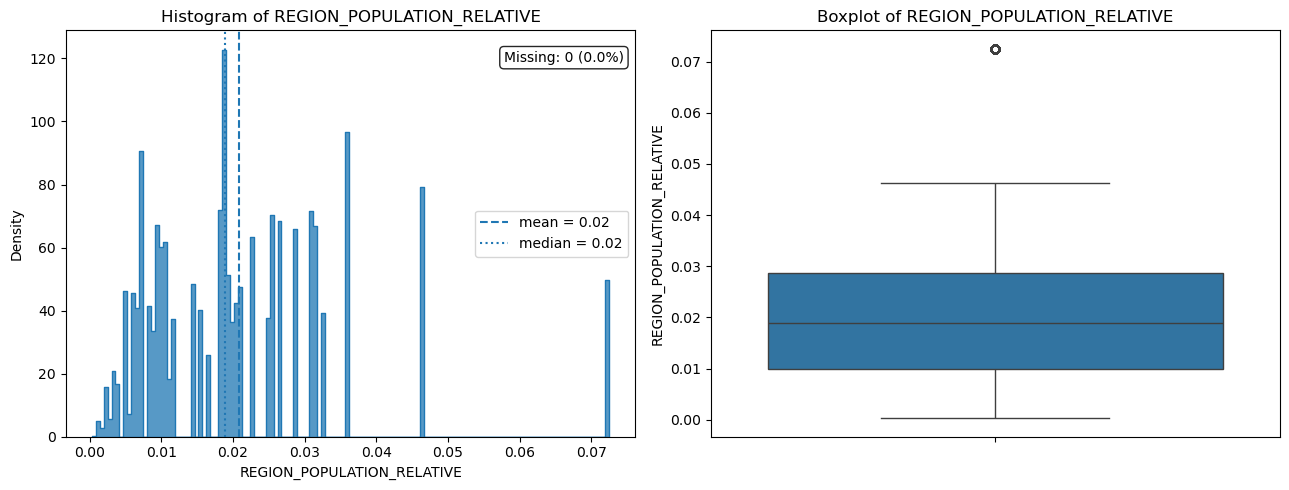

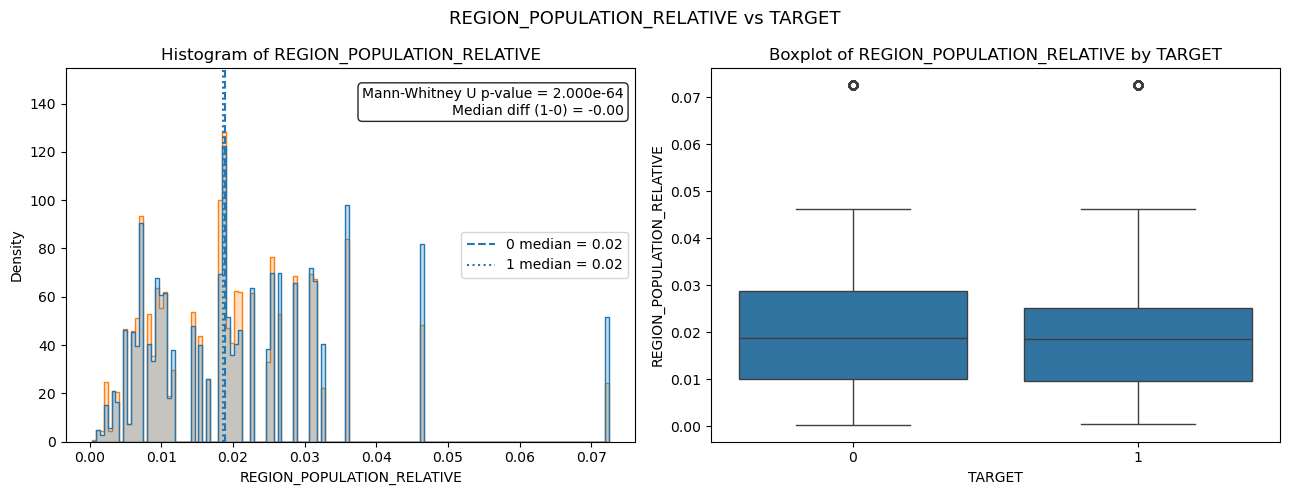

In [77]:
plot_quantitative_distribution(df=app_df, quant_var='REGION_POPULATION_RELATIVE')
plot_quantitative_vs_binary(df=app_df, quant_var='REGION_POPULATION_RELATIVE', target_var='TARGET')

In [83]:
region_population_relative_binned, binned_df, region_population_relative_binned_summary = bin_quantitative_var(
    df = app_df,
    quant_var='REGION_POPULATION_RELATIVE',
    quantiles_bins=True,
    target_var='TARGET',
    return_binned_quantiles=True,
    return_summary=True,
    return_df=True
)

region_population_relative_binned_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,REGION_POPULATION_RELATIVE,REGION_POPULATION_RELATIVE_binned_quantiles,quantiles,Q1,63155,0.205375,5649,57506,0.089447
1,REGION_POPULATION_RELATIVE,REGION_POPULATION_RELATIVE_binned_quantiles,quantiles,Q2,60969,0.198266,4830,56139,0.079221
2,REGION_POPULATION_RELATIVE,REGION_POPULATION_RELATIVE_binned_quantiles,quantiles,Q3,63143,0.205336,6028,57115,0.095466
3,REGION_POPULATION_RELATIVE,REGION_POPULATION_RELATIVE_binned_quantiles,quantiles,Q4,64025,0.208204,4947,59078,0.077267
4,REGION_POPULATION_RELATIVE,REGION_POPULATION_RELATIVE_binned_quantiles,quantiles,Q5,56219,0.182819,3371,52848,0.059962


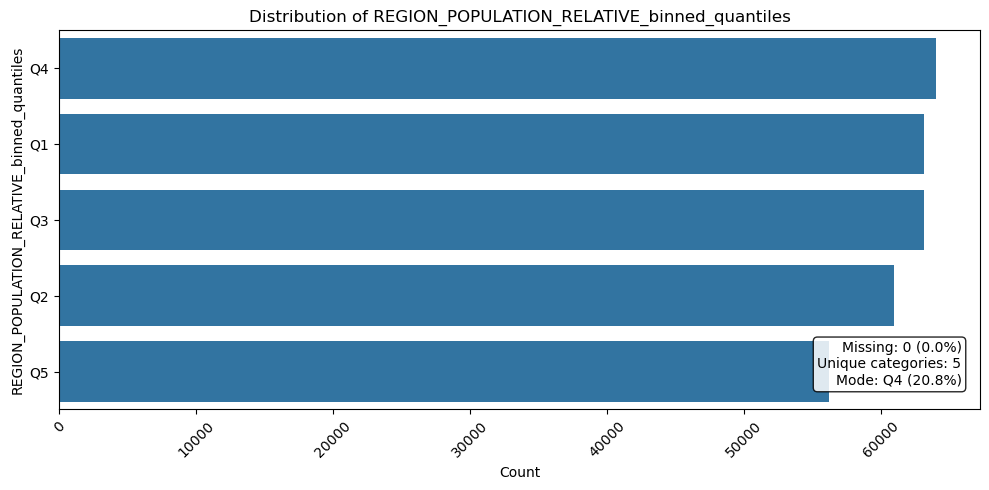

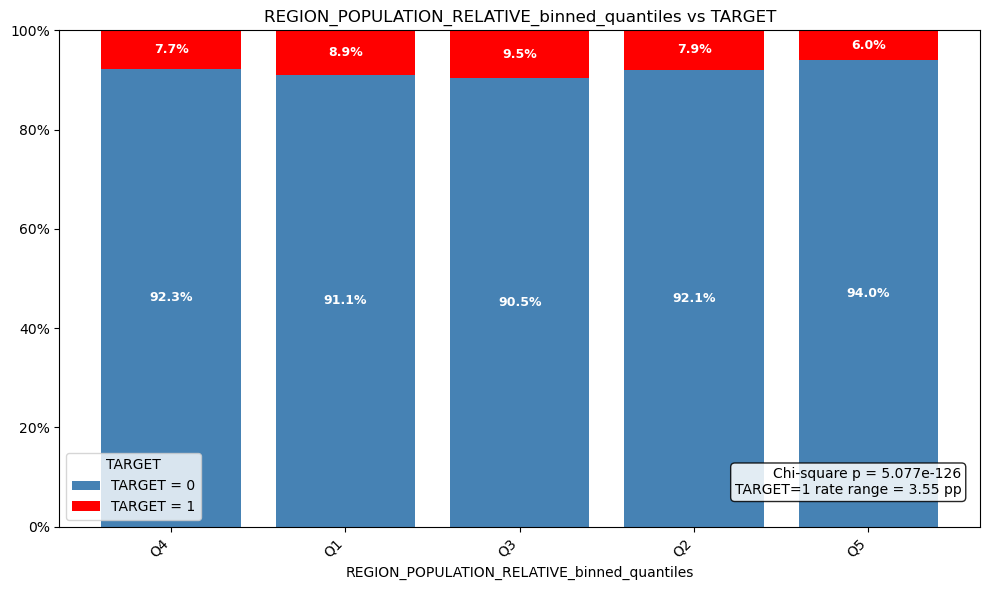

In [85]:
plot_categorical_distribution(df=binned_df, cat_var='REGION_POPULATION_RELATIVE_binned_quantiles')
plot_categorical_vs_binary(df=binned_df, cat_var='REGION_POPULATION_RELATIVE_binned_quantiles', target_var='TARGET')

Binned version of `REGION_POPULATION_RELATIVE` seems to unveil some dependecy between `REGION_POPULATION_RELATIVE` and `TARGET`.

## 2. REGION_RATING_CLIENT
Our rating of the region where client lives (1,2,3)

In [78]:
app_df['REGION_RATING_CLIENT'] = pd.Categorical(
    app_df['REGION_RATING_CLIENT'].astype(str),
    categories= ['1', '2', '3'],
    ordered=True
)

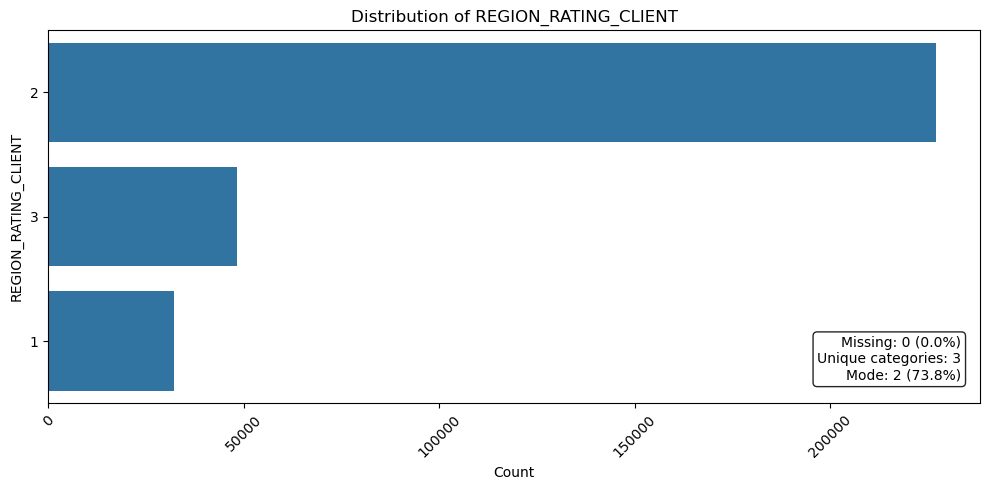

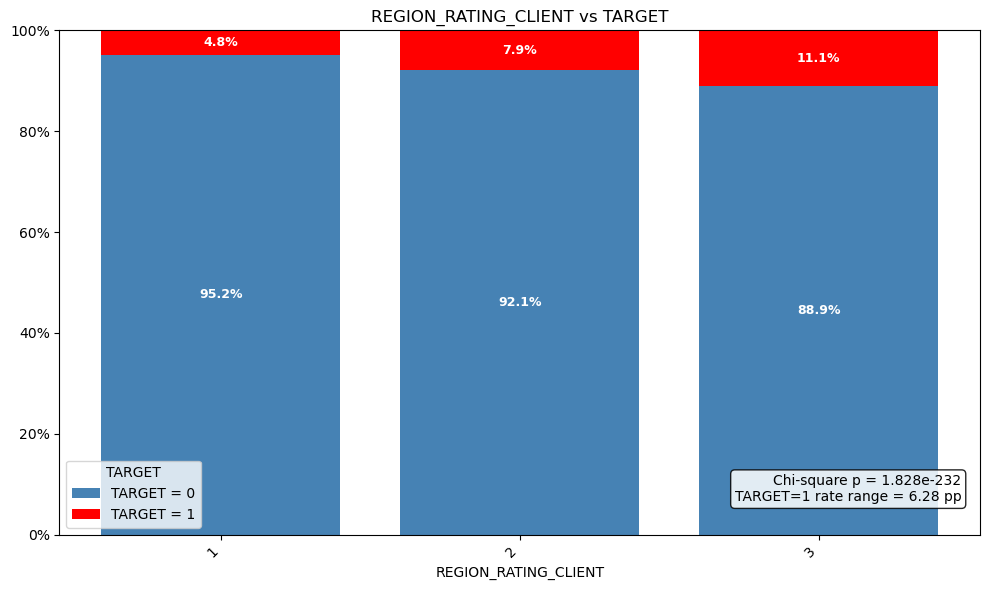

In [79]:
plot_categorical_distribution(df=app_df, cat_var='REGION_RATING_CLIENT', respect_category_order=False)
plot_categorical_vs_binary(df=app_df, cat_var='REGION_RATING_CLIENT', target_var='TARGET', respect_category_order=True)

`TARGET` values share depend on `REGION_RATING_CLIENT`.

## 3. REGION_RATING_CLIENT_W_CITY
Our rating of the region where client lives with taking city into account (1,2,3)

In [80]:
app_df['REGION_RATING_CLIENT_W_CITY'].value_counts()

REGION_RATING_CLIENT_W_CITY
2    229484
3     43860
1     34167
Name: count, dtype: int64

In [81]:
app_df['REGION_RATING_CLIENT_W_CITY'] = pd.Categorical(
    app_df['REGION_RATING_CLIENT_W_CITY'].astype(str),
    categories= ['1', '2', '3'],
    ordered=True
)

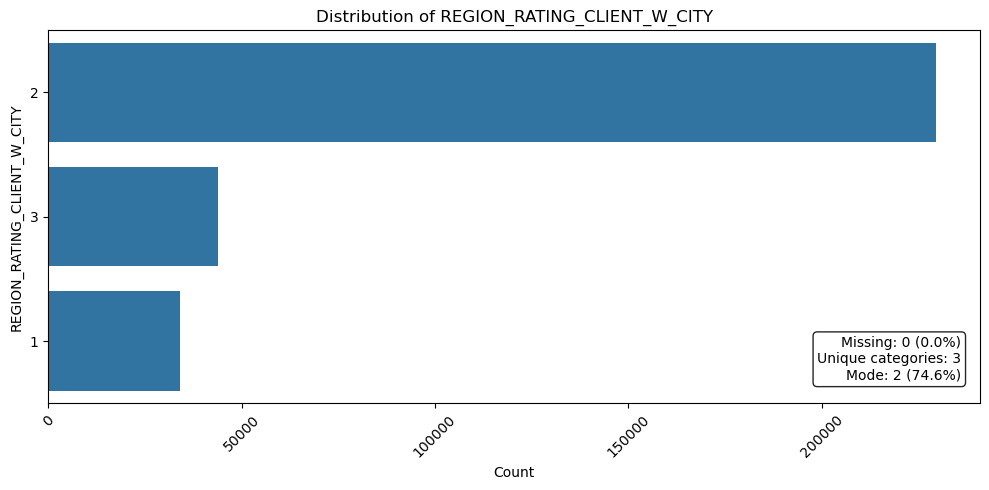

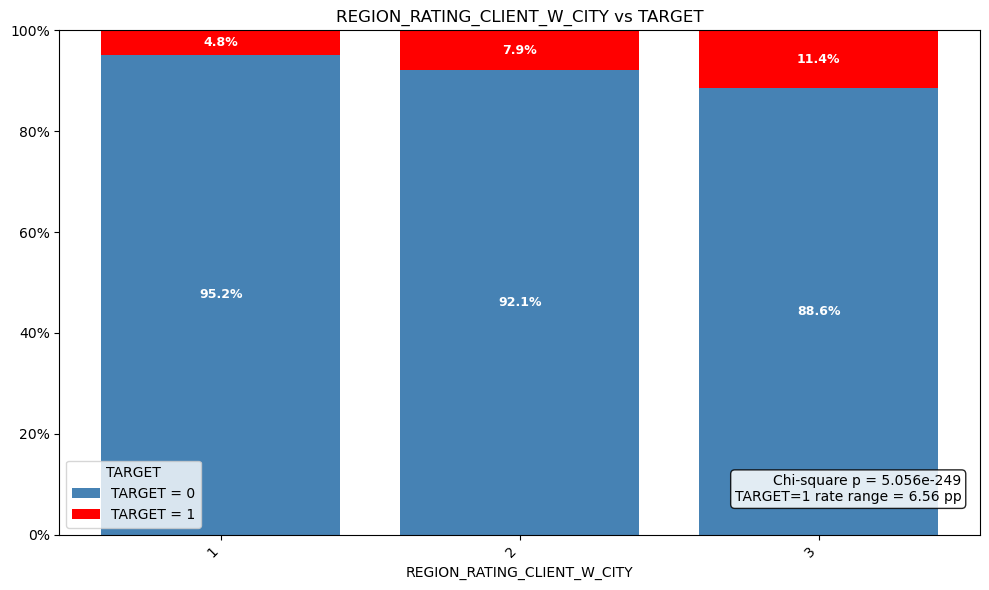

In [82]:
plot_categorical_distribution(df=app_df, cat_var='REGION_RATING_CLIENT_W_CITY', respect_category_order=False)
plot_categorical_vs_binary(df=app_df, cat_var='REGION_RATING_CLIENT_W_CITY', target_var='TARGET', respect_category_order=True)

`TARGET` values share also depend on `REGION_RATING_CLIENT_W_CITY` but it might be highly correlated with `REGION_RATING_CLIENT`.

## 4. Application living region data summary <br>
Variables that should be used as predictors
- REGION_POPULATION_RELATIVE
- REGION_POPULATION_RELATIVE_binned_quantiles
- REGION_RATING_CLIENT
- REGION_RATING_CLIENT_W_CITY